<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit7/Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

A polynomial element can represent practically any realistic relation between variables. Polynomials can do an excellent job matching matching discrete data. For a given dataset with n datapoints, there exists a polynomial of degree n-1 that passes through all the points. There is a chance of overfitting the model, but the model will be excellent if we ignore that fact. I find these models easier to interpret because they typically fit trends in scatterplots well (pretty smooth too!).

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

A simpler model is better usually because more complexity leads to more processing time. GLMs are more powerful in my opinion because there are so many conclusions we could draw from such data, so if there's a dataset with lots of linear relationships, a polynomial relationship wouldn't be the best direction to go. As I mentioned in the previous task, the model can have a tendency to overfit, which hurts the model more than it improves its accuracy.

**Task3**:

What's the point of using b splines?

I like to think of b splines as piecewise linear models. Since we can specify the number of "knots" that the spline has, bambi is able to run a mini linear regression on that small interval that the knot presides over and fit to the data well without running the risk of overfitting. B splines could also be made up of mini polynomial regressions. Combining the knots is useful because it minimizes overfitting.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

From what I gather, a gaussian process represents the distribution of possible functions that fit a set of data points. The only issue with this interpretation is that there are technically infinite functions that pass through a given set of points. Within the context of this class, we can use statistics to limit the possible amount of functions based on a confidence interval we choose (I think this is what the blue shading on our graphs mean). So similar to a neural network, a GP can collapse the infinite void of possibility, allowing us to find relationships within data.



**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install preliz
!pip install bambi

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

**Polynomial**

In [ ]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
poly1 = bmb.Model("height ~ poly(weight, degree=5)", howell)
idata_poly1 = poly1.fit()
# I'm not sure why it sampled 1999 instead of 2000 lol

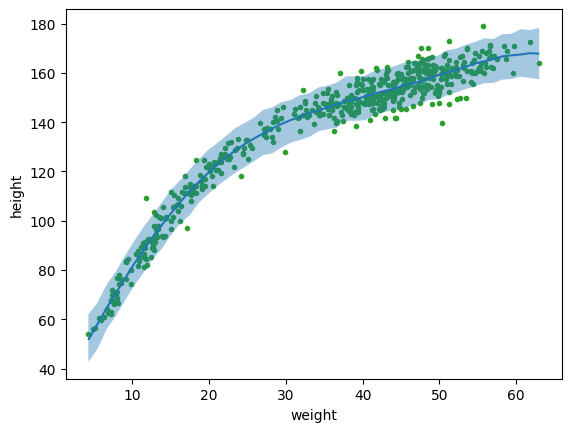

In [ ]:
bmb.interpret.plot_predictions(poly1, idata_poly1, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

**B spline**

In [ ]:
num_knots = 6
knots = np.linspace(howell.weight.min(), howell.weight.max(), num_knots+2)[1:-1]
model_spline_t = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline_t = model_spline_t.fit()

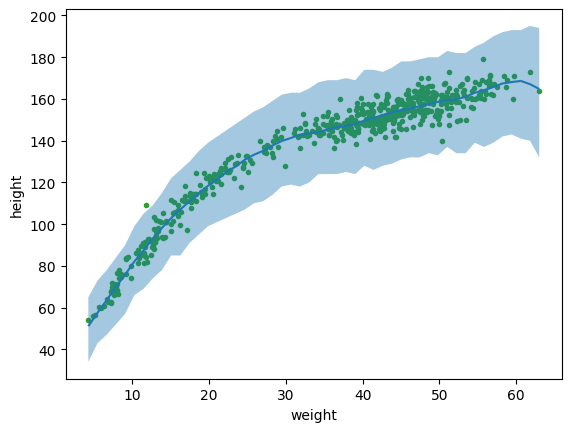

In [ ]:
bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

**Gaussian Process (approximated by HSGP)**

In [ ]:
height = howell["height"].values
weight = howell["weight"].values[:,None]

In [ ]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[howell.weight.min(), howell.weight.max()], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 3.3


In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(weight))
}

priors = {
    "hsgp(weight, m=168, c=3.3)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("height ~ 0 + hsgp(weight, m=168, c=3.3)", howell, family="negativebinomial", priors=priors)
idata_hsb = model_hsb.fit()


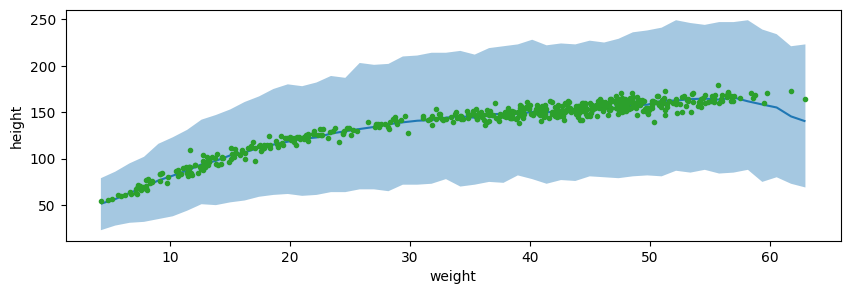

In [ ]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["weight"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["weight"].values, howell["height"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

One thing I learned is that GPs can incorporate uncertainty in the input variables, not only the outputs. This uncertainty in the inputs is propagated through the GP covariance function, leading to more realistic posterior predictions. I thought adding this was intelligent because it leads to more realistic resuts.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

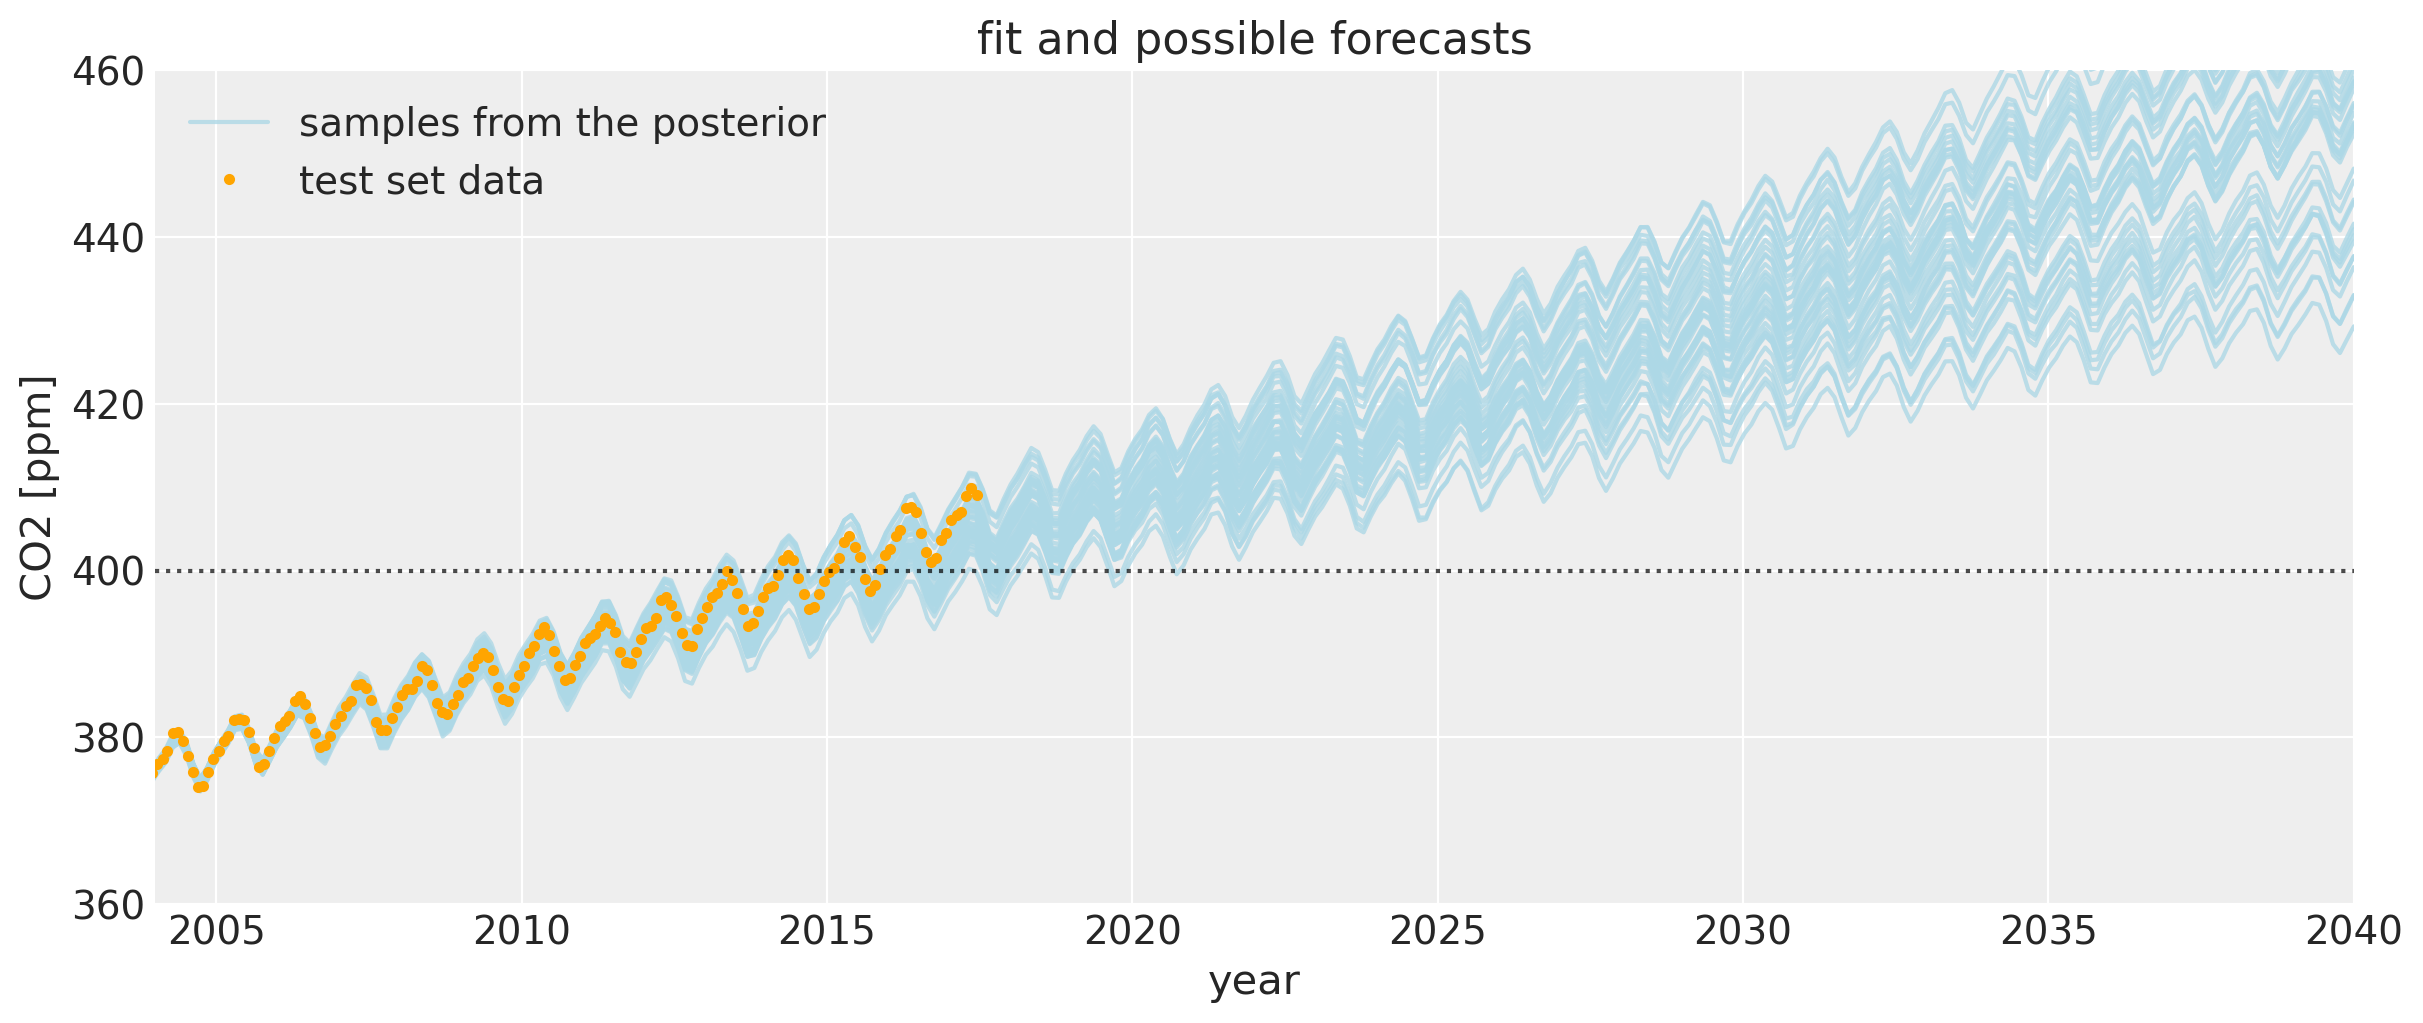

This is my favorite visualization because it looks cool. The samples from the posterior seem highly accurate. I've never been able to replicate a fit this good and I'm excited to make a project where I do something like this. I believe that the samples fit the data well because the uncertainty that the author added at the start. It improves the curves fit to the real data.